# Sprint 0 — 01: Introduction and data

## The brief

A literature review of the resources for doing data science in our chosen
domain: find books, websites and other resources that provide code, run their
examples, modify them to make our own visualisations of the data they analyse,
and combine the best into a report with a logical structure.
([Assessment 0](https://dsbristol.github.io/dst/assets/assessments/Assessment0.pdf))

## The domain

Our domain is **credit default risk**: predicting whether a borrower will fail
to repay. We chose it because it is a career interest.

The domain has labelled data, which Sprint 1 needs for a supervised problem.
We use the Taiwan credit-card dataset (Yeh, 2009). Each of its 30,000 customers
is labelled by whether they defaulted in October 2005, and 22% did. A second
labelled dataset, Statlog German Credit (Hofmann, 1994), was considered and
dropped because none of our analyses used it.

## What is in this report

* **01 (this notebook):** downloads the Taiwan data, checks it against its
  documentation, and cleans it. Every later notebook uses the clean file.
* **02-YehLien:** reproduces the logistic regression in the paper that
  introduced the data (Yeh & Lien, 2009), working from the text alone because
  no code was published.
* **03-Calibration:** runs scikit-learn's probability calibration example,
  then adapts it to fix the probabilities from 02.
* **04-Hazard Model Research:** research into the use of a hazard model to predict default.
* **05-Hazard Model - R:** application of Botha, Verster & Scheepers (2025) model.
* **08-MarkovChainModel:** Application of a Markov model onto our Taiwanese.

## The team

Oscar, Alex and Louis. Who wrote which part, and the agreed equity, are in the
[README](../README.md).

## Setup

Paths are built with `pathlib` from this notebook's location, so the report
runs the same on everyone's machine (the Python equivalent of the example
project's use of `fs` in R). The layout follows the unit's convention:

* `data/raw/` — downloaded once, never edited
* `data/processed/` — regenerated by the code, not committed
* `data/output/` — figures and tables the report keeps

In [3]:
from pathlib import Path
from urllib.request import urlretrieve

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent            # notebooks run from report/
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
OUTPUT = ROOT / "data" / "output"
for d in (RAW, PROCESSED, OUTPUT):
    d.mkdir(parents=True, exist_ok=True)

print("project root:", ROOT)

ModuleNotFoundError: No module named 'pandas'

## Importing the data

We use one public dataset, **Default of Credit Card Clients** (Yeh, 2009),
from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)
(doi:10.24432/C55S3H). It has 30,000 rows, one per cardholder, each labelled by
whether they defaulted the following month.

The file is downloaded into `data/raw/` the first time this notebook runs, and
is never edited there: anything we change is done in code, so the path from the
original file to every figure can be followed.

Reading it needs the `xlrd` package, because it is an old-format Excel `.xls`
(this is in `requirements.txt`).

In [ ]:
from zipfile import ZipFile

URL = "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip"
TAIWAN_DIR = RAW / "taiwan-credit-default"
TAIWAN_XLS = TAIWAN_DIR / "default of credit card clients.xls"

# Download and unzip only if the file isn't already in data/raw/
if not TAIWAN_XLS.exists():
    TAIWAN_DIR.mkdir(parents=True, exist_ok=True)
    zip_path, _ = urlretrieve(URL)          # to a temporary file
    with ZipFile(zip_path) as z:
        z.extractall(TAIWAN_DIR)

print("data file:", TAIWAN_XLS.relative_to(ROOT))

data file: data/raw/taiwan-credit-default/default of credit card clients.xls


### Taiwan credit card clients

One row per cardholder, from a Taiwanese bank in 2005. The spreadsheet has a
title row above the real column names, so we skip it (`header=1`), and use the
`ID` column as the row label. The label is `default payment next month`
(1 = defaulted). The columns are described on the UCI page: `LIMIT_BAL` is
the credit limit; `PAY_0`, `PAY_2`…`PAY_6` are repayment status for the last
six months (note there is no `PAY_1`); `BILL_AMT*` and `PAY_AMT*` are the bill
and payment amounts for the same months.

In [ ]:
taiwan = pd.read_excel(TAIWAN_XLS, header=1, index_col="ID")

print(taiwan.shape)                                             # expect (30000, 24)
print(taiwan["default payment next month"].value_counts())    # 1 = default
taiwan.head()

(30000, 24)
default payment next month
0    23364
1     6636
Name: count, dtype: int64


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# A quick sense check to insure we maintained the primiary structure of the data
assert taiwan.shape == (30000, 24), taiwan.shape
assert set(taiwan["default payment next month"]) == {0, 1}
print("Taiwan data loaded as expected.")

Taiwan data loaded as expected.


## Cleaning the Taiwan data

Before using the Taiwan file we checked it against its documentation: the UCI
page (Yeh, 2009) and the paper that introduced the data (Yeh & Lien, 2009,
p. 2475). Both describe the variables in the same words. We identified 5 details diverge from their accounts:

| # | What we found | What we do |
|---|---|---|
| 1 | The paper names the columns `X1`–`X23`. The file's short names skip from `PAY_0` to `PAY_2`, but the `X` row above them shows no month is missing: `PAY_0`, `BILL_AMT1` and `PAY_AMT1` are all September 2005 | Rename `PAY_0` to `PAY_1`, so the month numbers line up.  |
| 2 | Repayment status `PAY_*` uses -2 and 0, which the documentation doesn't list (it gives -1 = paid on time, 1–9 = months late). In September, 58% of customers have 0 | Keep them. These customers default far less often (about 13%) than those 2+ months late (about 70%), so dropping them would bias the sample. Treat -2, -1 and 0 as **categories**, not amounts of delay, when modelling |
| 3 | `EDUCATION` has codes 0, 5, 6 (345 people); only 1–4 are documented, 4 = others | Merge into 4, "others" |
| 4 | `MARRIAGE` has code 0 (54 people); only 1–3 are documented, 3 = others | Merge into 3, "others" |
| 5 | The paper reports 25,000 customers; the file has 30,000, with the same 22.12% default rate | We use all 30,000 datapoints available. We can't exactly reproduce the paper's sample |


The label, `default payment next month`, is October 2005, the month after the
last repayment status (Yeh & Lien, 2009, p. 2475).

### Duplicate rows

35 pairs of rows are identical in all 24 columns. Are they the same customer
recorded twice, or different customers who happen to match? We modelled each
column as an independent categorical distribution, within each type of
account, and worked out how many identical pairs chance alone would give (a
Poisson approximation, checked by simulation):

* About 16 pairs are expected by chance, but P(35 or more) ≈ 2 × 10⁻⁵, so
  chance doesn't explain them all.
* 30 pairs are "no-activity" accounts (every bill and payment 0). These
  need to match on only 7 columns, so coincidences are easy. About twice as
  many are seen as expected, but the test can't say *which* pairs are real.
  We keep them all.
* 5 pairs have the same non-zero bill and payment every month. Fewer than
  0.01 such pairs are expected by chance, so we treat them as real duplicates
  and drop the second copy.

Duplicates must go *before* any train/test split. Otherwise one copy can land
in each part, and the model is tested on a customer it has already seen.
Full working: [`Oscar/02-duplicates.ipynb`](../Oscar/02-duplicates.ipynb).

We remove duplicates first then recode.

In [ ]:
Y = "default payment next month"
BILLS = [c for c in taiwan.columns if c.startswith("BILL_AMT")]
PAYS  = [c for c in taiwan.columns if c.startswith("PAY_AMT")]

no_activity = (taiwan[BILLS + PAYS] == 0).all(axis=1)
same_every_month = ((taiwan[BILLS].nunique(axis=1) == 1)
                    & (taiwan[PAYS].nunique(axis=1) == 1) & ~no_activity)

# duplicated() marks the later copy of each pair, so the lower ID is kept
to_drop = taiwan.index[taiwan.duplicated() & same_every_month]
print("exact duplicate pairs:", taiwan.duplicated().sum())
print("IDs dropped:", list(to_drop))
assert len(to_drop) == 5

clean = taiwan.drop(index=to_drop)
clean.shape

exact duplicate pairs: 35
IDs dropped: [14295, 20876, 21882, 27352, 29266]


(29995, 24)

Then the recoding from the table: rename `PAY_0` (row 1) and merge the
undocumented `EDUCATION` and `MARRIAGE` codes into "others" (rows 3 and 4).
The `PAY_*` codes are left as they are (row 2), because how to encode them is a
modelling choice, not a fix to the data.

In [ ]:
clean = clean.rename(columns={"PAY_0": "PAY_1"})

print("before:", clean["EDUCATION"].value_counts().sort_index().to_dict(),
      clean["MARRIAGE"].value_counts().sort_index().to_dict())
clean["EDUCATION"] = clean["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
clean["MARRIAGE"] = clean["MARRIAGE"].replace({0: 3})
print("after: ", clean["EDUCATION"].value_counts().sort_index().to_dict(),
      clean["MARRIAGE"].value_counts().sort_index().to_dict())

before: {0: 14, 1: 10584, 2: 14027, 3: 4916, 4: 123, 5: 280, 6: 51} {0: 54, 1: 13656, 2: 15962, 3: 323}
after:  {1: 10584, 2: 14027, 3: 4916, 4: 468} {1: 13656, 2: 15962, 3: 377}


**Figure 1.1** shows why the undocumented `PAY_*` codes are kept, and why they
can't be read as numbers. For September's status, it shows the share of
customers in each code who defaulted in October. The two undocumented codes
(orange) default at the same low rate as -1, "paid on time". The step up comes
at 1 month late. So -2, -1 and 0 all mean roughly "not behind", and a model that
treats the codes as a count of months would wrongly place 0 between -1 and 1.
Codes 4–8 hold only 141 customers between them, so they are shown as one bar.

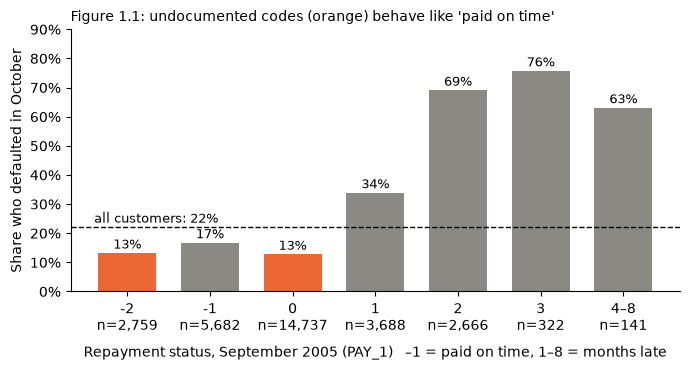

In [ ]:
status = clean["PAY_1"].clip(upper=4)          # 4-8 are rare: merge into one bar
by_code = clean.groupby(status)[Y].agg(rate="mean", n="size")
labels = [f"{k if k < 4 else '4–8'}\nn={n:,}" for k, n in by_code["n"].items()]
undocumented = by_code.index.isin([-2, 0])

ORANGE, GREY = "#eb6834", "#8a8984"
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(labels, by_code["rate"], width=0.7,
       color=[ORANGE if u else GREY for u in undocumented])
ax.axhline(clean[Y].mean(), color="black", lw=1, ls="--")
ax.text(-0.4, clean[Y].mean() + 0.015,
        f"all customers: {clean[Y].mean():.0%}", ha="left", fontsize=9)

for i, rate in enumerate(by_code["rate"]):
    ax.text(i, rate + 0.015, f"{rate:.0%}", ha="center", fontsize=9)

ax.set_xlabel("Repayment status, September 2005 (PAY_1)   "
              "–1 = paid on time, 1–8 = months late", labelpad=8)
ax.set_ylabel("Share who defaulted in October")
ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Figure 1.1: undocumented codes (orange) behave like 'paid on time'",
             loc="left", fontsize=10)
fig.tight_layout()
fig.savefig(OUTPUT / "fig1-1-default-by-status.png", dpi=150)
plt.show()

### Save

The clean data goes to `data/processed/taiwan-clean.csv`, which every later
notebook loads. It is made by this code and not committed, so this notebook
runs first.

In [ ]:
out = PROCESSED / "taiwan-clean.csv"
clean.to_csv(out)          # ID is written as the first column
print(out.relative_to(ROOT), clean.shape)

# Check it reads back identically
assert pd.read_csv(out, index_col="ID").equals(clean)
assert clean.shape == (29995, 24)

data/processed/taiwan-clean.csv (29995, 24)
